In [ ]:
from pathlib import Path

import torch
from diffusers import AutoPipelineForText2Image, StableDiffusionPipeline


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

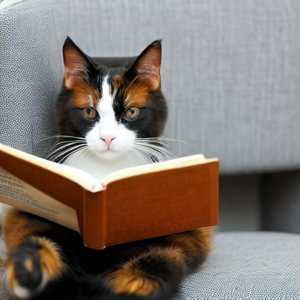

In [7]:
from IPython.display import display

model_path = "stable-diffusion-v1-5/stable-diffusion-v1-5"
pipeline = StableDiffusionPipeline.from_pretrained(
    model_path,
    torch_dtype=torch.float32,  # float16 causes issues on MPS, which generates black images
    use_safetensors=True,
)
pipeline.safety_checker = None
pipeline.requires_safety_checker = False

pipeline.to("mps")
pipeline.enable_attention_slicing()

prompt = "calico cat, reading a book, sitting on a chair, cute, detailed, 8k"
negative_prompt = "low quality, poor details, deformed, bad anatomy, paintings"

generator = torch.manual_seed(42)
image = pipeline(
    prompt=prompt,
    generator=generator,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
).images[0]

image.thumbnail((300, 300))
display(image)


In [ ]:
# Generating multiple images from a single prompt

dir_path = Path("./images/out")
dir_path.mkdir(parents=True, exist_ok=True)

model_path = "stable-diffusion-v1-5/stable-diffusion-v1-5"
pipeline = AutoPipelineForText2Image.from_pretrained(
    model_path,
    torch_dtype=torch.float32,
    use_safetensors=True,
)

pipeline.to("mps")
pipeline.enable_attention_slicing()
pipeline.enable_vae_slicing()

prompt = "calico cat, reading a book, sitting on a chair, cute, detailed, 8k"
negative_prompt = "low quality, poor details, deformed, bad anatomy, paintings"

image = pipeline(
    prompt=[prompt] * 3,
    negative_prompt=[negative_prompt] * 3,
).images

for i, image in enumerate(image, start=1):
    image_name = dir_path / f"01_{i}.png"
    image.save(image_name)


In [ ]:
# The effect of adjusting the strength parameter on the generated image
# The higher the strength, the more strongly the prompt influences the image

strengths = [1, 10, 20]
generator = torch.Generator("cpu").manual_seed(42)

for strength in strengths:
    image = pipeline(
        prompt=prompt,
        generator=generator,
        strength=strength,
    ).images[0]
    image_name = dir_path / f"strength_{strength}.png"
    image.save(image_name)


In [ ]:
# The effect of adjusting the number of inference steps on the generated image
# The higher the steps, the more detailed the image

dir_path = Path("./images/out")
dir_path.mkdir(parents=True, exist_ok=True)

pipeline.safety_checker = None
pipeline.requires_safety_checker = False

pipeline.enable_model_cpu_offload(device="mps")

inference_steps = [5, 10, 20, 30]
generator = torch.Generator("cpu").manual_seed(42)
for step in inference_steps:
    image = pipeline(
        prompt=prompt,
        generator=generator,
        num_inference_steps=step,
    ).images[0]
    image_name = dir_path / f"steps_{step}.png"
    image.save(image_name)
    print(f"Saved image {image_name}")


In [ ]:
# The effect of adjusting the CFG scale on the generated image
# The higher the scale, the more the image adheres to the prompt

cfg_scale = [1, 5, 10, 15, 20]
generator = torch.Generator("cpu").manual_seed(42)

for scale in cfg_scale:
    image = pipeline(
        prompt=prompt,
        generator=generator,
        guidance_scale=scale,
    ).images[0]
    image_name = dir_path / f"cfg_{scale}.png"
    image.save(image_name)


In [ ]:
# Saving intermediate images during the diffusion process
# https://huggingface.co/docs/diffusers/using-diffusers/callback#interrupt-the-diffusion-process


class StepInterruptor:
    def __init__(self, stop_fn):
        self.stop_fn = stop_fn

    def __call__(self, pipeline: StableDiffusionPipeline, i, t, callback_kwargs):
        """
        Callback function to save the image at a specific step.
        Args:
            pipeline: The diffusion pipeline.
            i: The current step index.
            t: The current timestep.
            callback_kwargs: Additional keyword arguments.
        """
        if self.stop_fn(i):
            print(f"Step {i}, saving image...")
            latents = callback_kwargs["latents"]
            with torch.no_grad():
                # latent scaling
                latents = latents / pipeline.vae.config.scaling_factor
                # VAE decode
                decoded_latents = pipeline.vae.decode(latents).sample
                # normalize to [0, 1]
                decoded_latents = (decoded_latents / 2 + 0.5).clamp(0, 1)

            image = pipeline.image_processor.postprocess(
                decoded_latents, output_type="pil"
            )[0]
            image.save(dir_path / f"steps02-{i}_new.png")
        return callback_kwargs


num_inference_steps = 20
interruptor = StepInterruptor(stop_fn=lambda i: i > 0 and i % 5 == 0)

pipeline(
    prompt=prompt,
    generator=generator,
    num_inference_steps=num_inference_steps,
    callback_on_step_end=interruptor,
)